# Detectar Anomalias

- FILE1AA_MODIFICADO: humedad, master speed, nivel banda tolva, flujo aceite, temp salida intercambiador, deltaTpid
- FILEJUNIO:          humedad, master speed, nivel aceite actual PID, nivel aceite actual, flujo aceite. deltaTpid
- FILEJULIO:          same filejunio
- FILE1JULIO:         same filejunio
- FILE1A3:            humedad, master spped, nivel aceite actual, deltaTPID


## 1. FILEJUNIO

- FILEJUNIO:          humedad, master speed, nivel aceite actual PID, nivel aceite actual, flujo aceite. deltaTpid


### Isolation Forest

 Funciona construyendo múltiples árboles de aislamiento (Isolation Trees) y utilizando la profundidad de estos árboles para determinar si un punto de datos es una anomalía.


 La profundidad de un punto de datos en un árbol de aislamiento es el número de divisiones necesarias para aislar ese punto.


Los puntos de datos que son anomalías tienden a ser aislados más rápidamente (en menos divisiones) porque están en regiones escasamente pobladas del espacio de características.

La puntuación de anomalía de un punto de datos se calcula como la media de las profundidades de ese punto en todos los árboles de aislamiento.
Esta puntuación se normaliza para que esté en el rango [0, 1], donde los valores más cercanos a 1 indican una mayor probabilidad de ser una anomalía.

**Contamination:** proporción datos que es anomalia. Por defecto es 0.1. Pero si se sabe historicamente de la data que se tiene que la proporción de anomalias es mayor, se puede cambiar este valor.

In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

df.shape
# Seleccionar las columnas relevantes para el modelo
features = ['Pc_OIT_24Real[000]', 'Pc_OIT_24Real[004]', 'DeltaTPid.Pid_SP', 'Pc_OIT_24Real[001]Pid.Pid_SP', 'Pc_OIT_24Real[001]', 'FT1501.Value']
X = df[features]

# Calcular el valor común general (mediana) para cada feature
medians = X.median()

# Aplicar Isolation Forest
model = IsolationForest(contamination='auto', random_state=42) # o de 0.01 a 0.5
df['anomaly'] = model.fit_predict(X)

# Mostrar la cantidad de filas con anomalías
num_anomalies = df[df['anomaly'] == -1].shape[0]
print(f'Cantidad de filas con anomalías: {num_anomalies}')


C:\Users\josef\AppData\Local\Temp\ipykernel_2260\2868303712.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


Cantidad de filas con anomalías: 5742


In [23]:
# Mostrar las anomalías y los valores anómalos
anomalies = df[df['anomaly'] == -1]
#print('Filas con anomalías:')
#print(anomalies)

print('Valores comunes generales (medianas) por cada feature:')
print(medians)
print('-------------------------------------------------------')
print('Anomalías detectadas:')
for index, row in anomalies.iterrows():
    print(f'Fila {index}:')
    for feature in features:
        if row[feature] != medians[feature]:
            print(f'  {feature}: {row[feature]}')
print('-------------------------------------------------------')



Valores comunes generales (medianas) por cada feature:
Pc_OIT_24Real[000]                 1.328551
Pc_OIT_24Real[004]                78.000000
DeltaTPid.Pid_SP                  10.988420
Pc_OIT_24Real[001]Pid.Pid_SP     215.000000
Pc_OIT_24Real[001]               211.476700
FT1501.Value                    3016.489000
dtype: float64
-------------------------------------------------------
Anomalías detectadas:
Fila 405:
  Pc_OIT_24Real[000]: 0.6879631
  Pc_OIT_24Real[004]: 90.0
  DeltaTPid.Pid_SP: 2.629064
  Pc_OIT_24Real[001]Pid.Pid_SP: 190.0
  Pc_OIT_24Real[001]: 210.3774
  FT1501.Value: 3047.622
Fila 779:
  Pc_OIT_24Real[000]: 1.112357
  Pc_OIT_24Real[004]: 100.0
  DeltaTPid.Pid_SP: 11.38204
  Pc_OIT_24Real[001]Pid.Pid_SP: 190.0
  Pc_OIT_24Real[001]: 208.0058
  FT1501.Value: 3034.912
Fila 1144:
  Pc_OIT_24Real[000]: 0.7599382
  Pc_OIT_24Real[004]: 111.0
  DeltaTPid.Pid_SP: 2.136316
  Pc_OIT_24Real[001]Pid.Pid_SP: 190.0
  Pc_OIT_24Real[001]: 205.5733
  FT1501.Value: 3019.987
Fila 1185:

Estos gráficos te ayudarán a identificar patrones y posibles anomalías en tus datos.



- Grafico de dispersion: relacin entre cada par de caracteristicas en los datos. Puntos alejados del resto de los datos, son puntos qque pueden ser considerados como anomalias.
- Histogramas: distribucion de cada caracteristica en los datos.Barras alejadas del resto de la distribucion, pueden indicar valores atipicos. Eje X, valores de la caracteristica. Eje Y, frecuencia de observaciones que caen dentro de cada intervalo del eje X. 
- Boxplot: distribucion de cada caracteristica en los datos. Puntos fuera de los bigotes, pueden ser considerados anomalia. 


C:\Users\josef\AppData\Local\Temp\ipykernel_2260\3571696133.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])


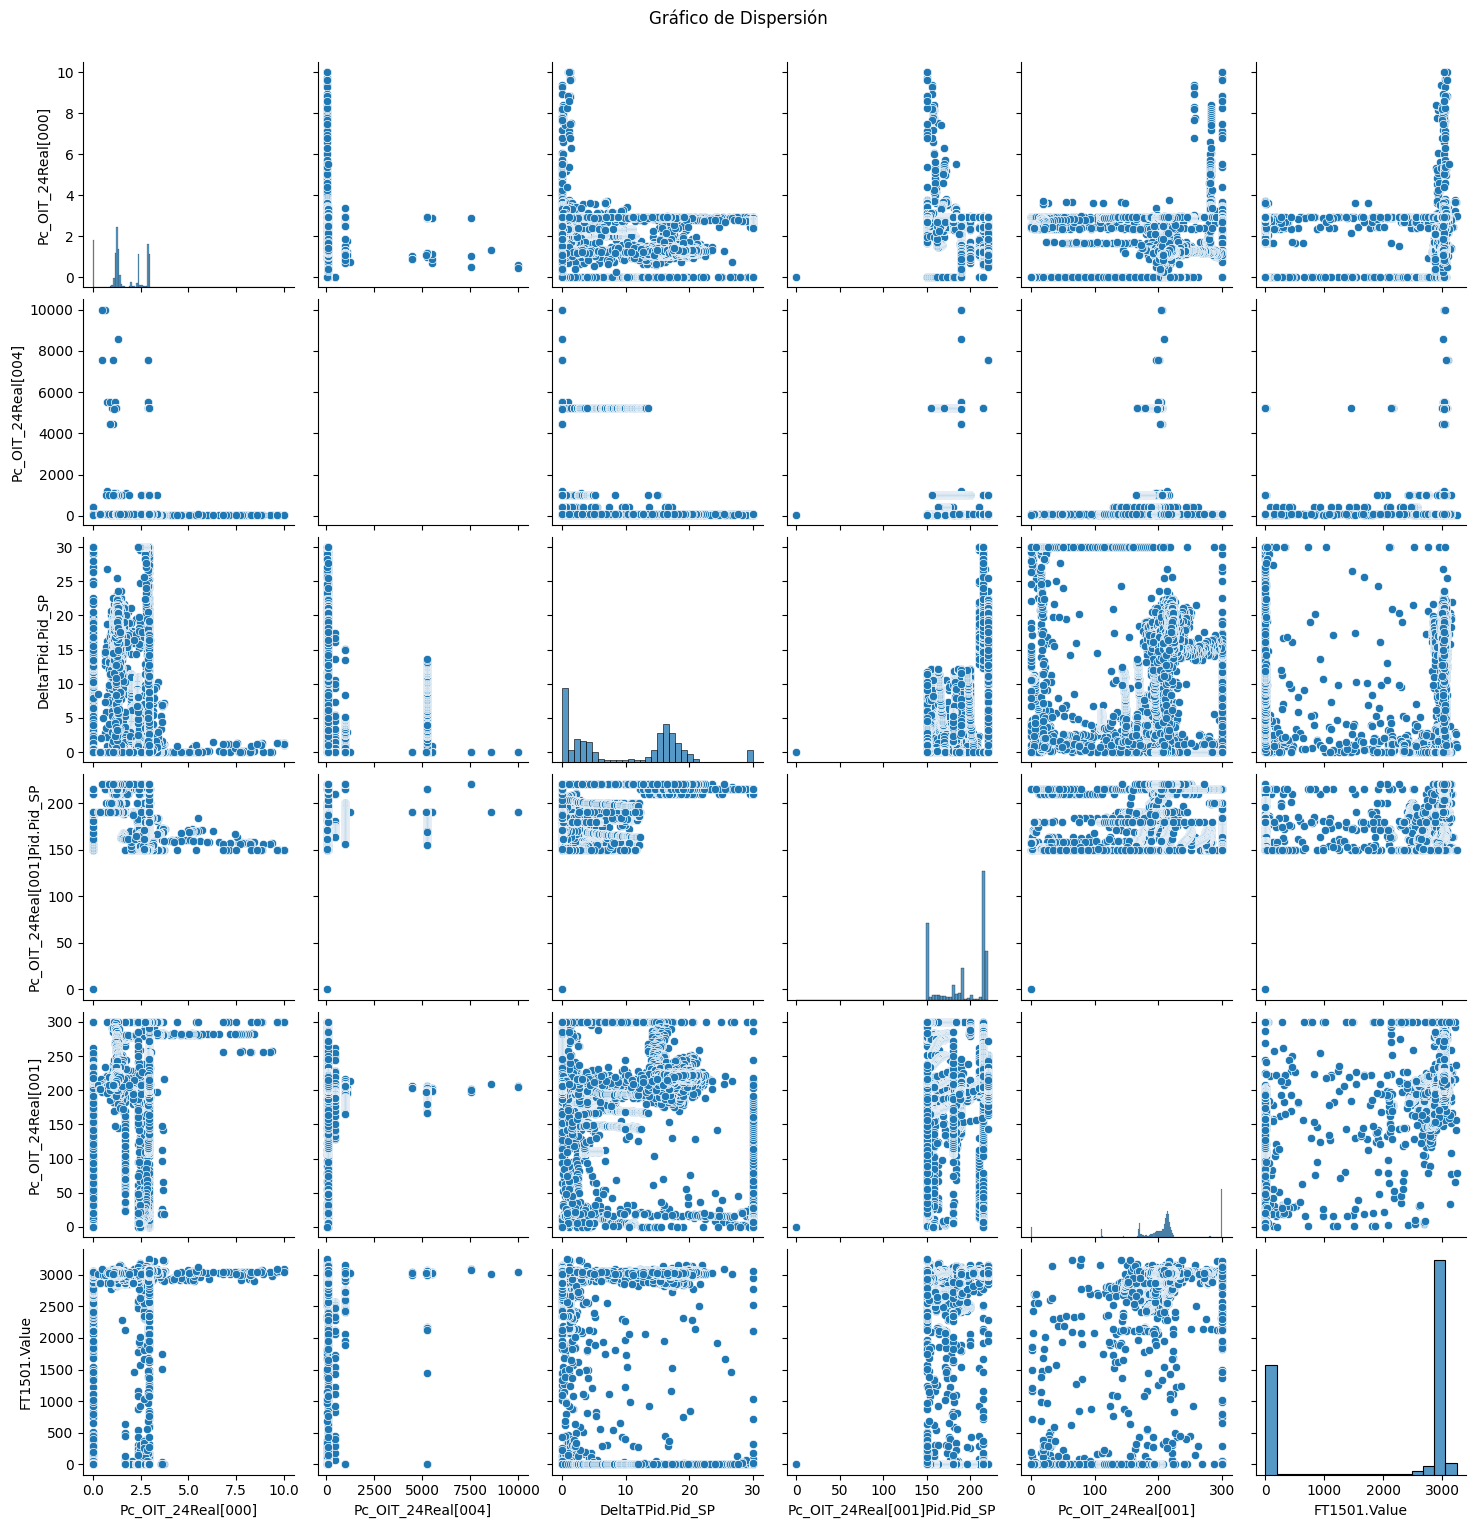

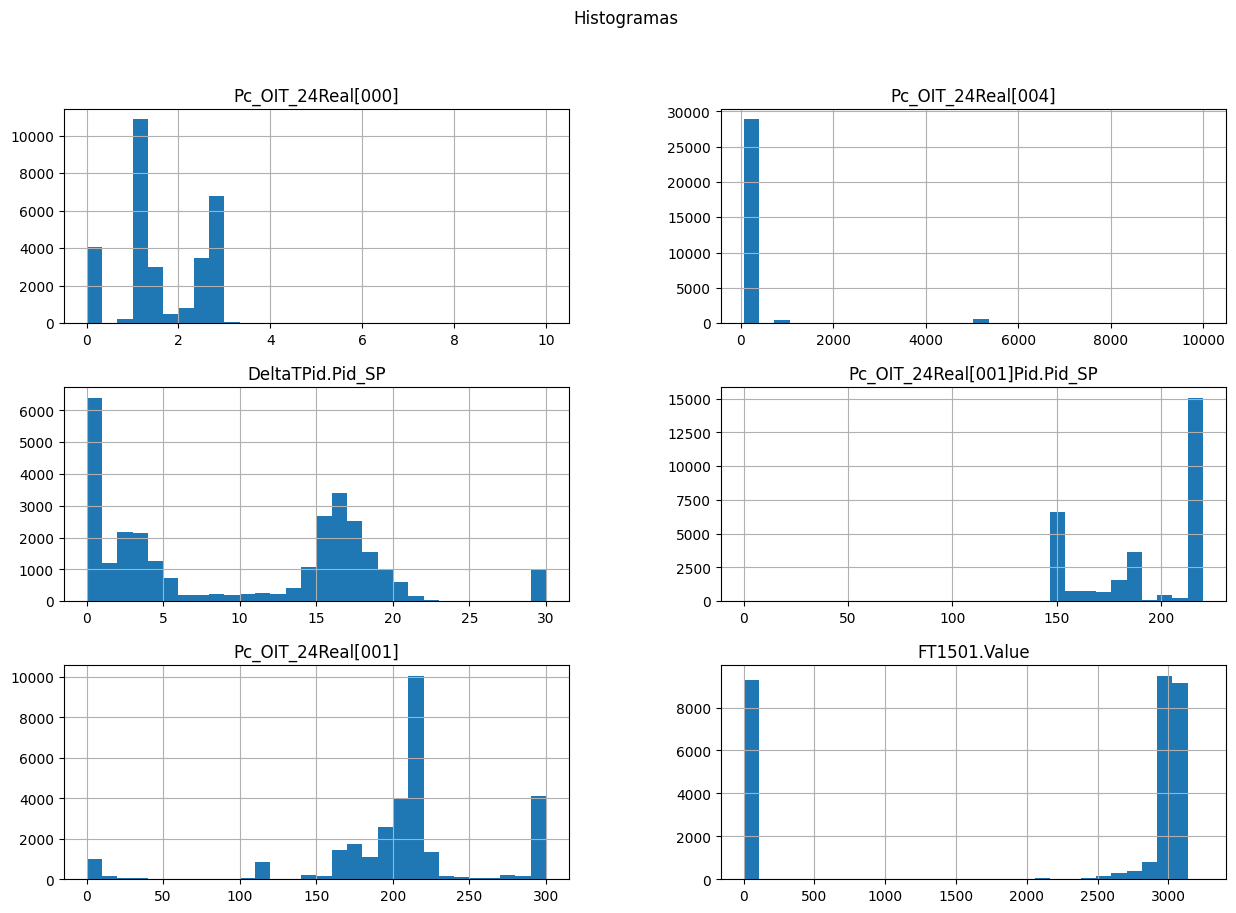

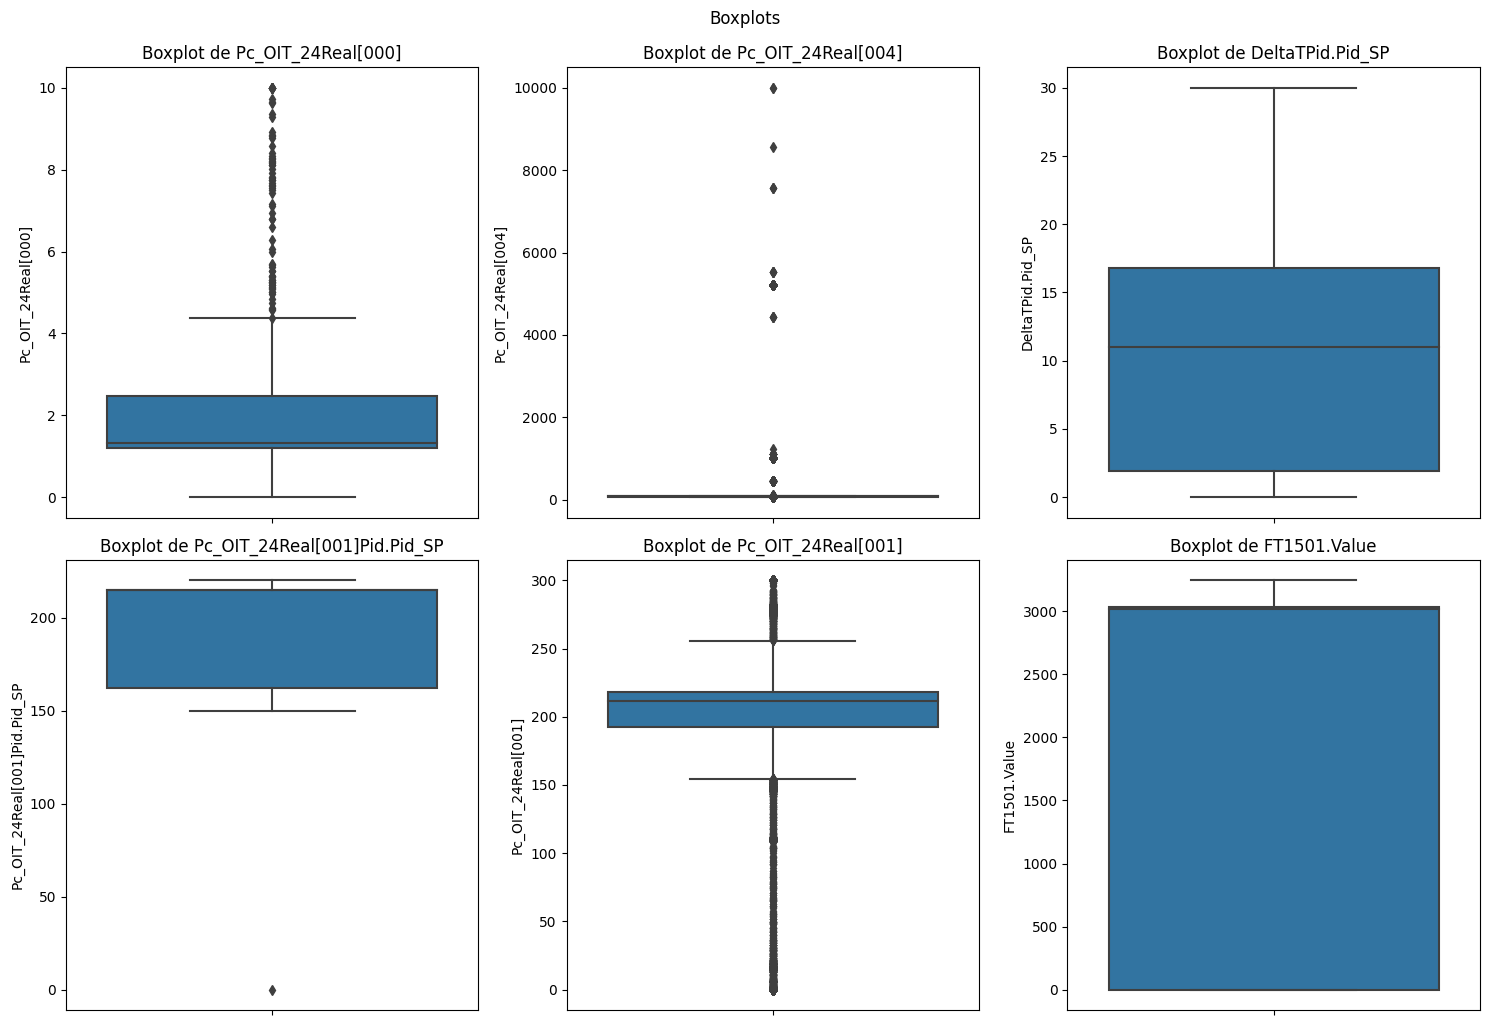

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer el archivo CSV
df = pd.read_csv('CSV Completo/FILEJUNIO.CSV')

# Convertir las columnas de fecha y hora en un solo datetime
df['Datetime'] = pd.to_datetime(df['$Date'] + ' ' + df['$Time'])
df = df.drop(columns=['$Date', '$Time'])

# Eliminar filas con datos nulos
df = df.dropna()

# Seleccionar las columnas relevantes para el análisis
features = ['Pc_OIT_24Real[000]', 'Pc_OIT_24Real[004]', 'DeltaTPid.Pid_SP', 'Pc_OIT_24Real[001]Pid.Pid_SP', 'Pc_OIT_24Real[001]', 'FT1501.Value']

# Gráfico de dispersión
sns.pairplot(df[features])
plt.suptitle('Gráfico de Dispersión', y=1.02)
plt.show()

# Histogramas
df[features].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histogramas')
plt.show()

# Boxplots
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.suptitle('Boxplots', y=1.02)
plt.show()

### ARIMA

### LSTM

## 2. FILE1AA_MODIFICADO

- FILE1AA_MODIFICADO: humedad, master speed, nivel banda tolva, flujo aceite, temp salida intercambiador, deltaTpid
